# Option B — Data Acquisition Discovery Notebook

**Purpose:** Explore and acquire raw data for Option B.
Raw data -> `../../product/data/raw/` | Cleaned data -> `../modified_data/`

**Sources**
1. CMS Provider Data Catalog (DKAN metastore) — ED timeliness OP-18b
2. US Census ACS 5-Year 2022 — state poverty, income, uninsured, population
3. NPI Registry — primary care physician counts by state

> **API Change:** CMS migrated from Socrata to DKAN.
> Old: `data.cms.gov/resource/yv7e-xc69.json` (deprecated)
> New: metastore `schemas/dataset/items/yv7e-xc69` → datastore query or direct CSV download.

In [1]:
!pip install dotenv

Defaulting to user installation because normal site-packages is not writeable


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


In [2]:
import json
import time
import pathlib
import requests
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()  # loads CENSUS_API_KEY from repo-root .env

RAW = pathlib.Path("../../product/data/raw")
MOD = pathlib.Path("../modified_data")
RAW.mkdir(parents=True, exist_ok=True)
MOD.mkdir(parents=True, exist_ok=True)

CENSUS_KEY = os.getenv("CENSUS_API_KEY", "")
print("Raw dir :", RAW.resolve())
print("Census key present:", bool(CENSUS_KEY))

Raw dir : D:\OneDrive - University of Toronto\UofT\Year3\Winter\jsc370\JSC370-Midterm-Proj\option-b-ed-timeliness\product\data\raw
Census key present: True


---
## 1. CMS Timely and Effective Care (DKAN Metastore → Datastore)

### Step 1a — Discover dataset metadata and distribution IDs

In [3]:
DATASET_ID = "yv7e-xc69"  # Timely and Effective Care - Hospital
META_URL = (
    "https://data.cms.gov/provider-data/api/1/metastore"
    f"/schemas/dataset/items/{DATASET_ID}"
)

meta = requests.get(META_URL, params={"show-reference-ids": "true"}, timeout=30).json()

# Persist full metadata snapshot for reproducibility
(RAW / f"cms_ed_meta_{DATASET_ID}.json").write_text(json.dumps(meta, indent=2))

print("Title    :", meta.get("title"))
print("Modified :", meta.get("modified"))
print("# distrib:", len(meta.get("distribution", [])))

Title    : Timely and Effective Care - Hospital
Modified : 2026-01-27
# distrib: 1


In [4]:
# Inspect all distributions — find CSV download URL and/or datastore resource IDs
distributions = meta.get("distribution", [])
for i, d in enumerate(distributions):
    dat = d.get("data", {})
    print(f"[{i}] id={d.get('identifier')}")
    print(f"     mediaType  = {dat.get('mediaType')}")
    print(f"     downloadURL= {dat.get('downloadURL', 'N/A')[:100]}")
    print()

[0] id=5affca6f-96f2-51ee-995f-9e61013b754b
     mediaType  = text/csv
     downloadURL= https://data.cms.gov/provider-data/sites/default/files/resources/0437b5494ac61507ad90f2af6b8085a7_17



### Step 1b — Direct CSV download (preferred: no pagination needed)

In [5]:
csv_dist = next(
    (d for d in distributions
     if "csv" in d.get("data", {}).get("mediaType", "").lower()),
    None
)

if csv_dist:
    csv_url = csv_dist["data"]["downloadURL"]
    print("CSV URL:", csv_url[:120])
    df_full = pd.read_csv(csv_url)
    print("Shape  :", df_full.shape)
    print("Columns:", df_full.columns.tolist())
else:
    print("No CSV distribution found — use Step 1c (datastore API)")

CSV URL: https://data.cms.gov/provider-data/sites/default/files/resources/0437b5494ac61507ad90f2af6b8085a7_1770163650/Timely_and_


Shape  : (138129, 16)
Columns: ['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Condition', 'Measure ID', 'Measure Name', 'Score', 'Sample', 'Footnote', 'Start Date', 'End Date']


C:\Users\user\AppData\Local\Temp\ipykernel_61828\2567396425.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(csv_url)


In [6]:
# Identify column names (may vary between CMS data releases)
measure_col = next((c for c in df_full.columns if "measure" in c.lower() and "id" in c.lower()), None)
score_col   = next((c for c in df_full.columns if "score"   in c.lower()), None)
state_col   = next((c for c in df_full.columns if c.lower() == "state"), None)

print("measure_col:", measure_col)
print("score_col  :", score_col)
print("state_col  :", state_col)
print()
print("Top measure IDs:")
print(df_full[measure_col].value_counts().head(15))

measure_col: Measure ID
score_col  : Score
state_col  : State

Top measure IDs:
Measure ID
EDV                                       4657
GMCS                                      4657
GMCS_Malnutrition_Diagnosis_Documented    4657
GMCS_Malnutrition_Screening               4657
GMCS_Nutrition_Assessment                 4657
GMCS_Nutritional_Care_Plan                4657
HH_HYPER                                  4657
HH_HYPO                                   4657
HH_ORAE                                   4657
IMM_3                                     4657
OP_18a                                    4657
OP_18b                                    4657
OP_18c                                    4657
OP_18d                                    4657
OP_22                                     4657
Name: count, dtype: int64


In [7]:
# Filter to OP-18b — adjust TARGET_MEASURE if column uses different casing
TARGET_MEASURE = "OP_18b"
df_op18b = df_full[df_full[measure_col].str.strip().str.upper() == TARGET_MEASURE.upper()].copy()
df_op18b[score_col] = pd.to_numeric(df_op18b[score_col], errors="coerce")

print(f"Rows for {TARGET_MEASURE}: {len(df_op18b)}")
print(f"Score range: {df_op18b[score_col].min():.0f} – {df_op18b[score_col].max():.0f} min")
df_op18b.head(10)

Rows for OP_18b: 4657
Score range: 38 – 456 min


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Condition,Measure ID,Measure Name,Score,Sample,Footnote,Start Date,End Date
11,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Emergency Department,OP_18b,Average (median) time patients spent in the em...,208.0,392,NaN,04/01/2024,03/31/2025
41,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Emergency Department,OP_18b,Average (median) time patients spent in the em...,137.0,1122,NaN,04/01/2024,03/31/2025
71,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Emergency Department,OP_18b,Average (median) time patients spent in the em...,146.0,319,NaN,04/01/2024,03/31/2025
101,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Emergency Department,OP_18b,Average (median) time patients spent in the em...,121.0,1069,NaN,04/01/2024,03/31/2025
131,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Emergency Department,OP_18b,Average (median) time patients spent in the em...,109.0,353,NaN,04/01/2024,03/31/2025
161,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Emergency Department,OP_18b,Average (median) time patients spent in the em...,158.0,169,"3, 29",04/01/2024,03/31/2025
191,010012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DE KALB,(256) 845-3150,Emergency Department,OP_18b,Average (median) time patients spent in the em...,156.0,366,NaN,04/01/2024,03/31/2025
221,010016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,SHELBY,(205) 620-8100,Emergency Department,OP_18b,Average (median) time patients spent in the em...,190.0,426,NaN,04/01/2024,03/31/2025
251,010018,CALLAHAN EYE HOSPITAL,1720 UNIVERSITY BLVD STE 305,BIRMINGHAM,AL,35233,JEFFERSON,(205) 325-8596,Emergency Department,OP_18b,Average (median) time patients spent in the em...,124.0,380,NaN,04/01/2024,03/31/2025
281,010019,HELEN KELLER HOSPITAL,1300 SOUTH MONTGOMERY AVENUE,SHEFFIELD,AL,35660,COLBERT,(256) 386-4556,Emergency Department,OP_18b,Average (median) time patients spent in the em...,184.0,351,NaN,04/01/2024,03/31/2025


In [8]:
out = RAW / "cms_ed_timeliness_op18b.csv"
df_op18b.to_csv(out, index=False)
print("Saved:", out)

Saved: ..\..\product\data\raw\cms_ed_timeliness_op18b.csv


---
## 2. US Census ACS 5-Year 2022 — State-Level Covariates

In [9]:
ACS_BASE = "https://api.census.gov/data/2022/acs/acs5"

# Mapping from Census variable codes -> human-readable column names
# Used to (1) document what we are pulling and (2) drive the rename in the next cell
ACS_VAR_LABELS = {
    "B17001_002E": "poverty_below",     # persons below poverty level
    "B17001_001E": "poverty_universe",  # total with known poverty status (denominator)
    "B01003_001E": "population",        # total population
    "B19013_001E": "median_income",     # median household income
}

acs_vars = ",".join(["NAME"] + list(ACS_VAR_LABELS))

raw_acs = requests.get(
    ACS_BASE,
    params={"get": acs_vars, "for": "state:*", "key": CENSUS_KEY},
    timeout=30
).json()

(RAW / "acs_state_2022.json").write_text(json.dumps(raw_acs, indent=2))
df_acs = pd.DataFrame(raw_acs[1:], columns=raw_acs[0])
print("ACS shape:", df_acs.shape)
df_acs.head(10)

ACS shape: (52, 6)


,NAME,B17001_002E,B17001_001E,B01003_001E,B19013_001E,state
0,Alabama,768897,4890427,5028092,59609,01
1,Alaska,75227,717293,734821,86370,02
2,Arizona,916876,7017776,7172282,72581,04
3,Arkansas,475729,2931377,3018669,56335,05
4,California,4685272,38643585,39356104,91905,06
5,Colorado,540105,5653289,5770790,87598,08
6,Connecticut,355692,3507563,3611317,90213,09
7,Delaware,107790,969075,993635,79325,10
8,District of Columbia,98039,649184,670587,101722,11
9,Florida,2725633,21171700,21634529,67917,12


In [10]:
# Uninsured rate from ACS subject tables
# S2701_C04_001E = % uninsured, civilian noninstitutionalized population
raw_unins = requests.get(
    "https://api.census.gov/data/2022/acs/acs5/subject",
    params={"get": "NAME,S2701_C04_001E", "for": "state:*", "key": CENSUS_KEY},
    timeout=30
).json()

(RAW / "acs_uninsured_state_2022.json").write_text(json.dumps(raw_unins, indent=2))
df_unins = pd.DataFrame(raw_unins[1:], columns=raw_unins[0])
df_unins = df_unins.rename(columns={"S2701_C04_001E": "uninsured_pct"})
df_unins["uninsured_pct"] = pd.to_numeric(df_unins["uninsured_pct"], errors="coerce")
print("Uninsured shape:", df_unins.shape)
df_unins.head(10)

Uninsured shape: (52, 3)


,NAME,uninsured_pct,state
0,Alabama,472079,01
1,Alaska,82562,02
2,Arizona,759133,04
3,Arkansas,261691,05
4,California,2752067,06
5,Colorado,443740,08
6,Connecticut,184112,09
7,Delaware,58735,10
8,District of Columbia,22592,11
9,Florida,2620725,12


In [11]:
code_cols = list(ACS_VAR_LABELS)  # ["B17001_002E", "B17001_001E", ...]
df_acs[code_cols] = df_acs[code_cols].apply(pd.to_numeric, errors="coerce")

# Derived rate
df_acs["poverty_rate"] = df_acs["B17001_002E"] / df_acs["B17001_001E"] * 100

# Rename using the mapping dict
df_acs = df_acs.rename(columns=ACS_VAR_LABELS)

df_acs_full = df_acs.merge(df_unins[["state", "uninsured_pct"]], on="state", how="left")
df_acs_full[["NAME", "poverty_rate", "population", "median_income", "uninsured_pct"]].head(5)

,NAME,poverty_rate,population,median_income,uninsured_pct
0,Alabama,15.722492,5028092,59609,472079
1,Alaska,10.487625,734821,86370,82562
2,Arizona,13.065051,7172282,72581,759133
3,Arkansas,16.228858,3018669,56335,261691
4,California,12.124320,39356104,91905,2752067


---
## 3. NPI Registry — Primary Care Physician Counts by State

> **Note:** Full pull (51 states × 4 taxonomies) takes ~20–40 min.
> Each (state, taxonomy) batch is cached as a JSON file; re-runs are instant.

In [12]:
NPI_URL = "https://npiregistry.cms.hhs.gov/api/"

# Quick probe: CA / Family Medicine
probe_npi = requests.get(NPI_URL, params={
    "version": "2.1", "enumeration_type": "NPI-1",
    "taxonomy_description": "Family Medicine",
    "state": "CA", "limit": 5, "skip": 0,
}, timeout=30).json()

print("Result count CA/Family Medicine:", probe_npi.get("result_count"))
if probe_npi.get("results"):
    print("Sample NPI:", probe_npi["results"][0].get("number"))

Result count CA/Family Medicine: 5
Sample NPI: 1558454207


In [13]:
STATES = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","DC","FL","GA","HI","ID","IL","IN",
    "IA","KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH",
    "NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT",
    "VT","VA","WA","WV","WI","WY"
]
TAXONOMIES = ["Family Medicine", "Internal Medicine", "General Practice", "Pediatrics"]
MAX_SKIP = 1200  # NPI Registry hard cap: returns at most 1200 results per query

NPI_RAW_DIR = RAW / "npi_pcp"
NPI_RAW_DIR.mkdir(exist_ok=True)
npi_summary = {}  # state -> unique PCP count

for state in STATES:
    state_npis = set()
    for taxonomy in TAXONOMIES:
        cache = NPI_RAW_DIR / f"npi_{state}_{taxonomy.replace(' ', '_')}.json"
        if cache.exists():
            records = json.loads(cache.read_text())
            print(f"  {state}/{taxonomy}: cached ({len(records)} records)", flush=True)
        else:
            print(f"  {state}/{taxonomy}: fetching ...", flush=True)
            records, skip = [], 0
            while True:
                print(f"    page {skip // 200 + 1} (skip={skip}) ...", end=" ", flush=True)
                r = requests.get(NPI_URL, params={
                    "version": "2.1", "enumeration_type": "NPI-1",
                    "taxonomy_description": taxonomy,
                    "state": state, "limit": 200, "skip": skip,
                }, timeout=30)
                if r.status_code != 200:
                    print(f"HTTP {r.status_code} — stopping", flush=True)
                    break
                batch = r.json().get("results", [])
                print(f"got {len(batch)}", flush=True)
                if not batch:
                    break
                records.extend(batch)
                if len(batch) < 200 or skip >= MAX_SKIP:
                    break
                skip += 200
                time.sleep(0.15)
            cache.write_text(json.dumps(records))
        state_npis.update(rec["number"] for rec in records if rec.get("number"))
    npi_summary[state] = len(state_npis)
    print(f"{state}: {len(state_npis)} unique PCPs", flush=True)

(RAW / "npi_pcp_state_counts.json").write_text(json.dumps(npi_summary, indent=2))
print("Done — NPI summary saved.")

  AL/Family Medicine: cached (1400 records)


  AL/Internal Medicine: cached (1400 records)


  AL/General Practice: cached (1400 records)


  AL/Pediatrics: cached (577 records)


AL: 4119 unique PCPs


...

  WY/Internal Medicine: cached (232 records)


  WY/General Practice: cached (316 records)


  WY/Pediatrics: cached (33 records)


WY: 1078 unique PCPs


Done — NPI summary saved.


---
## Backup — Persist Processed Data to product/data/raw/

All three raw sources are already persisted during acquisition.
This cell additionally saves the *processed* ACS table so ACS variables
can be reloaded without re-calling the Census API.

In [14]:
# --- CMS ---
# cms_ed_timeliness_op18b.csv already written by Step 1b (cell above)
print("CMS  :", (RAW / "cms_ed_timeliness_op18b.csv").exists(),
      "|", (RAW / "cms_ed_timeliness_op18b.csv").stat().st_size, "bytes")

# --- ACS ---
# Raw JSON already written in Section 2; save the processed DataFrame as CSV
acs_out = RAW / "acs_state_2022_processed.csv"
df_acs_full.to_csv(acs_out, index=False)
print("ACS  :", acs_out.name, "|", acs_out.stat().st_size, "bytes",
      "|", len(df_acs_full), "rows")

# --- NPI ---
# Per-pair JSON cache + npi_pcp_state_counts.json already written in Section 3
# Also save summary as CSV for convenience
npi_csv_out = RAW / "npi_pcp_state_counts.csv"
pd.DataFrame(list(npi_summary.items()), columns=["state_abbr", "unique_pcp_count"]).to_csv(
    npi_csv_out, index=False)
print("NPI  :", npi_csv_out.name, "|", npi_csv_out.stat().st_size, "bytes",
      "|", len(npi_summary), "states")

print("All backups confirmed in:", RAW.resolve())

CMS  : True | 1365000 bytes
ACS  : acs_state_2022_processed.csv | 3655 bytes | 52 rows
NPI  : npi_pcp_state_counts.csv | 488 bytes | 51 states
All backups confirmed in: D:\OneDrive - University of Toronto\UofT\Year3\Winter\jsc370\JSC370-Midterm-Proj\option-b-ed-timeliness\product\data\raw


---
## 4. Preliminary Join — State Analysis Table

Saves `state_analysis_table.csv` to `modified_data/` for EDA notebooks.

In [15]:
STATE_NAME_TO_ABBR = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","District of Columbia":"DC",
    "Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID","Illinois":"IL",
    "Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
    "Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN",
    "Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR",
    "Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA",
    "Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY",
}
df_acs_full["state_abbr"] = df_acs_full["NAME"].map(STATE_NAME_TO_ABBR)

df_npi = pd.DataFrame(list(npi_summary.items()), columns=["state_abbr", "pcp_count"])
df_merged = df_acs_full.merge(df_npi, on="state_abbr", how="left")
df_merged["pcp_per_100k"] = df_merged["pcp_count"] / (df_merged["population"] / 100_000)
print("Merged shape:", df_merged.shape)
df_merged.head(10)

Merged shape: (52, 11)


,NAME,poverty_below,poverty_universe,population,median_income,state,poverty_rate,uninsured_pct,state_abbr,pcp_count,pcp_per_100k
0,Alabama,768897,4890427,5028092,59609,01,15.722492,472079,AL,4119.0,81.919742
1,Alaska,75227,717293,734821,86370,02,10.487625,82562,AK,1746.0,237.608887
2,Arizona,916876,7017776,7172282,72581,04,13.065051,759133,AZ,4287.0,59.771771
3,Arkansas,475729,2931377,3018669,56335,05,16.228858,261691,AR,3827.0,126.777729
4,California,4685272,38643585,39356104,91905,06,12.124320,2752067,CA,4766.0,12.109939
5,Colorado,540105,5653289,5770790,87598,08,9.553819,443740,CO,4627.0,80.179663
6,Connecticut,355692,3507563,3611317,90213,09,10.140716,184112,CT,4353.0,120.537743
7,Delaware,107790,969075,993635,79325,10,11.122978,58735,DE,2377.0,239.222652
8,District of Columbia,98039,649184,670587,101722,11,15.101882,22592,DC,2734.0,407.702505
9,Florida,2725633,21171700,21634529,67917,12,12.873945,2620725,FL,4740.0,21.909421


In [16]:
# Aggregate CMS hospitals to state median ED wait
df_cms = pd.read_csv(RAW / "cms_ed_timeliness_op18b.csv")
score_col = next((c for c in df_cms.columns if "score" in c.lower()), "Score")
state_col = next((c for c in df_cms.columns if c.lower() == "state"),  "State")
df_cms[score_col] = pd.to_numeric(df_cms[score_col], errors="coerce")

df_state_ed = (
    df_cms.groupby(state_col)
    .agg(ed_wait_median=(score_col, "median"), n_hospitals=(score_col, "count"))
    .reset_index()
    .rename(columns={state_col: "state_abbr"})
)
print("State ED rows:", len(df_state_ed))
df_state_ed.sort_values("ed_wait_median", ascending=False).head(10)

State ED rows: 56


,state_abbr,ed_wait_median,n_hospitals
8,DC,328.5,6
42,PR,296.0,6
22,MD,241.5,40
21,MA,228.0,54
43,RI,226.0,10
9,DE,222.0,6
37,NY,208.0,140
7,CT,195.0,26
41,PA,189.0,137
30,NC,186.5,94


In [17]:
df_analysis = df_state_ed.merge(df_merged, on="state_abbr", how="left")
print("Analysis table shape:", df_analysis.shape)
print("Null ED wait  :", df_analysis["ed_wait_median"].isna().sum())
print("Null pcp/100k :", df_analysis["pcp_per_100k"].isna().sum())

out = MOD / "state_analysis_table.csv"
df_analysis.to_csv(out, index=False)
print("Saved:", out)
df_analysis[["state_abbr", "ed_wait_median", "poverty_rate", "pcp_per_100k", "uninsured_pct"]].head(10)

Analysis table shape: (56, 13)
Null ED wait  : 3
Null pcp/100k : 5
Saved: ..\modified_data\state_analysis_table.csv


,state_abbr,ed_wait_median,poverty_rate,pcp_per_100k,uninsured_pct
0,AK,128.0,10.487625,237.608887,82562.0
1,AL,146.0,15.722492,81.919742,472079.0
2,AR,131.0,16.228858,126.777729,261691.0
3,AS,NaN,NaN,NaN,NaN
4,AZ,183.0,13.065051,59.771771,759133.0
5,CA,178.0,12.124320,12.109939,2752067.0
6,CO,132.0,9.553819,80.179663,443740.0
7,CT,195.0,10.140716,120.537743,184112.0
8,DC,328.5,15.101882,407.702505,22592.0
9,DE,222.0,11.122978,239.222652,58735.0


## 5) Additional EDA (No Model Fitting)

These cells add exploratory visuals and summary tables using the assembled `df_analysis` table.
Outputs are saved under `../results/` and `../modified_data/`.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

RESULTS = pathlib.Path("../results")
RESULTS.mkdir(parents=True, exist_ok=True)

US51 = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"
}

df_eda = df_analysis.copy()
for col in ["ed_wait_median", "n_hospitals", "poverty_rate", "uninsured_pct", "pcp_per_100k", "population", "median_income"]:
    if col in df_eda.columns:
        df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

df_eda = df_eda[df_eda["state_abbr"].isin(US51)].copy()

print("EDA rows (US51):", len(df_eda))
print("Results dir:", RESULTS.resolve())


EDA rows (US51): 51
Results dir: D:\OneDrive - University of Toronto\UofT\Year3\Winter\jsc370\JSC370-Midterm-Proj\option-b-ed-timeliness\discover\results


In [19]:
df_desc = (
    df_eda[["state_abbr", "ed_wait_median", "poverty_rate", "uninsured_pct", "pcp_per_100k", "n_hospitals", "population", "median_income"]]
    .sort_values("ed_wait_median", ascending=False)
    .reset_index(drop=True)
)

slow10 = set(df_desc.head(10)["state_abbr"])
fast10 = set(df_desc.tail(10)["state_abbr"])
df_desc["speed_flag"] = np.select(
    [df_desc["state_abbr"].isin(slow10), df_desc["state_abbr"].isin(fast10)],
    ["Top 10 slowest", "Top 10 fastest"],
    default=""
)

desc_out = MOD / "state_ed_descriptive_ranked.csv"
df_desc.to_csv(desc_out, index=False)
print("Saved:", desc_out)

df_desc.head(15)


Saved: ..\modified_data\state_ed_descriptive_ranked.csv


,state_abbr,ed_wait_median,poverty_rate,uninsured_pct,pcp_per_100k,n_hospitals,population,median_income,speed_flag
0,DC,328.5,15.101882,22592.0,407.702505,6,670587.0,101722.0,Top 10 slowest
1,MD,241.5,9.256503,360485.0,76.975423,40,6161707.0,98461.0,Top 10 slowest
2,MA,228.0,9.928116,185907.0,68.540371,54,6984205.0,96505.0,Top 10 slowest
3,RI,226.0,11.222118,46445.0,226.822024,10,1094250.0,81370.0,Top 10 slowest
4,DE,222.0,11.122978,58735.0,239.222652,6,993635.0,79325.0,Top 10 slowest
5,NY,208.0,13.606940,1031600.0,23.841701,140,19994379.0,81386.0,Top 10 slowest
6,CT,195.0,10.140716,184112.0,120.537743,26,3611317.0,90213.0,Top 10 slowest
7,PA,189.0,11.782104,719332.0,36.815178,137,12989208.0,73170.0,Top 10 slowest
8,NC,186.5,13.326108,1077458.0,45.490952,94,10470214.0,66186.0,Top 10 slowest
9,NJ,185.5,9.681402,685567.0,51.064632,60,9249063.0,97126.0,Top 10 slowest


C:\Users\user\AppData\Local\Temp\ipykernel_61828\2000734177.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


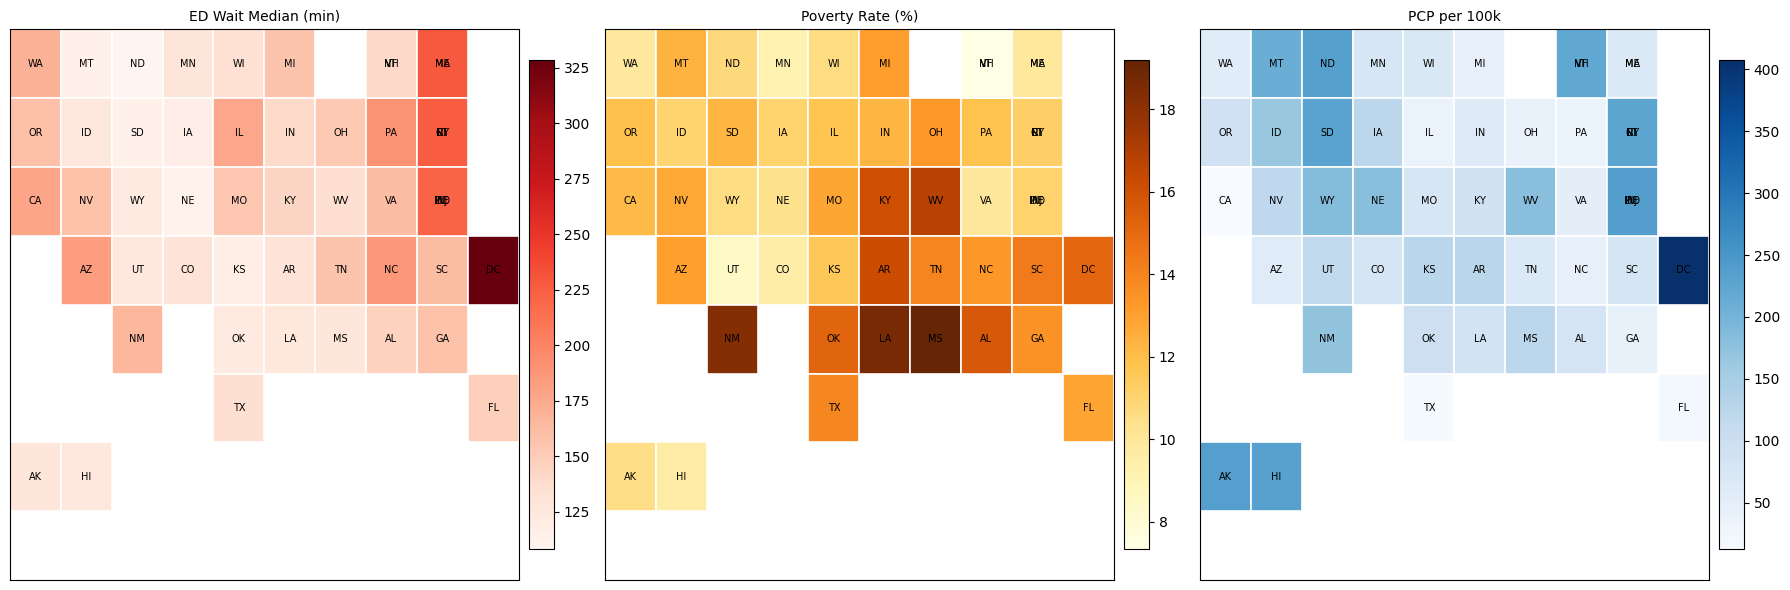

Saved: ..\results\eda_option_b_state_tilemaps.png


In [20]:
STATE_TILE_POS = {
    "WA": (0, 0), "MT": (1, 0), "ND": (2, 0), "MN": (3, 0), "WI": (4, 0), "MI": (5, 0), "VT": (7, 0), "ME": (8, 0),
    "OR": (0, 1), "ID": (1, 1), "SD": (2, 1), "IA": (3, 1), "IL": (4, 1), "IN": (5, 1), "OH": (6, 1), "PA": (7, 1), "NY": (8, 1),
    "CA": (0, 2), "NV": (1, 2), "WY": (2, 2), "NE": (3, 2), "MO": (4, 2), "KY": (5, 2), "WV": (6, 2), "VA": (7, 2), "MD": (8, 2),
    "AZ": (1, 3), "UT": (2, 3), "CO": (3, 3), "KS": (4, 3), "AR": (5, 3), "TN": (6, 3), "NC": (7, 3), "SC": (8, 3), "DC": (9, 3),
    "NM": (2, 4), "OK": (4, 4), "LA": (5, 4), "MS": (6, 4), "AL": (7, 4), "GA": (8, 4),
    "TX": (4, 5), "FL": (9, 5),
    "AK": (0, 6), "HI": (1, 6),
    "NH": (7, 0), "MA": (8, 0), "CT": (8, 1), "RI": (8, 1), "NJ": (8, 2), "DE": (8, 2)
}

def draw_tile(ax, df, value_col, title, cmap_name):
    vals = dict(zip(df["state_abbr"], df[value_col]))
    series = np.array([v for v in vals.values() if pd.notna(v)])
    norm = mpl.colors.Normalize(vmin=float(np.nanmin(series)), vmax=float(np.nanmax(series)))
    cmap = mpl.cm.get_cmap(cmap_name)

    for st, (x, y) in STATE_TILE_POS.items():
        v = vals.get(st, np.nan)
        color = "#eeeeee" if pd.isna(v) else cmap(norm(v))
        rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor="white", linewidth=1.2)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, st, ha="center", va="center", fontsize=7)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.045, pad=0.02)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
draw_tile(axes[0], df_eda, "ed_wait_median", "ED Wait Median (min)", "Reds")
draw_tile(axes[1], df_eda, "poverty_rate", "Poverty Rate (%)", "YlOrBr")
draw_tile(axes[2], df_eda, "pcp_per_100k", "PCP per 100k", "Blues")
fig.tight_layout()

tile_out = RESULTS / "eda_option_b_state_tilemaps.png"
fig.savefig(tile_out, dpi=220)
plt.show()
print("Saved:", tile_out)


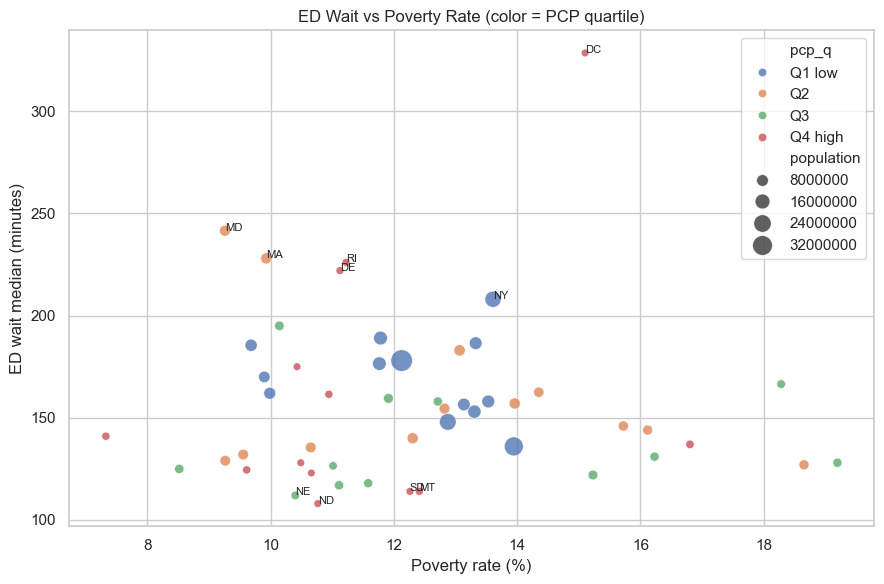

Saved: ..\results\eda_option_b_scatter_wait_vs_poverty.png


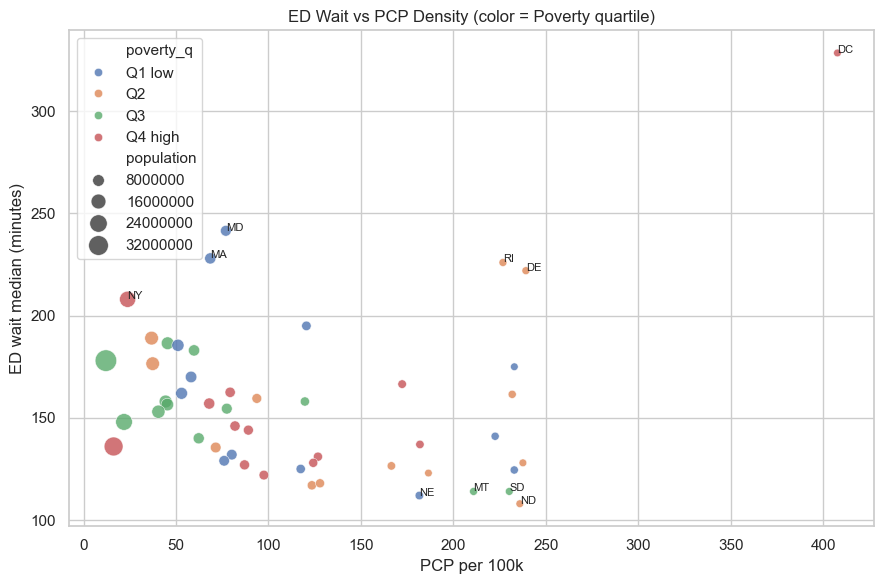

Saved: ..\results\eda_option_b_scatter_wait_vs_pcp.png


In [21]:
sns.set_theme(style="whitegrid")

plot_df = df_eda.dropna(subset=["ed_wait_median", "poverty_rate", "pcp_per_100k", "population"]).copy()
plot_df["pcp_q"] = pd.qcut(plot_df["pcp_per_100k"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"], duplicates="drop")
plot_df["poverty_q"] = pd.qcut(plot_df["poverty_rate"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"], duplicates="drop")

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="poverty_rate",
    y="ed_wait_median",
    hue="pcp_q",
    size="population",
    sizes=(30, 240),
    alpha=0.78,
    ax=ax,
)
ax.set_title("ED Wait vs Poverty Rate (color = PCP quartile)")
ax.set_xlabel("Poverty rate (%)")
ax.set_ylabel("ED wait median (minutes)")

for _, row in pd.concat([plot_df.nlargest(6, "ed_wait_median"), plot_df.nsmallest(4, "ed_wait_median")]).drop_duplicates("state_abbr").iterrows():
    ax.text(row["poverty_rate"], row["ed_wait_median"], row["state_abbr"], fontsize=8)

fig.tight_layout()
scatter1_out = RESULTS / "eda_option_b_scatter_wait_vs_poverty.png"
fig.savefig(scatter1_out, dpi=220)
plt.show()
print("Saved:", scatter1_out)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="pcp_per_100k",
    y="ed_wait_median",
    hue="poverty_q",
    size="population",
    sizes=(30, 240),
    alpha=0.78,
    ax=ax,
)
ax.set_title("ED Wait vs PCP Density (color = Poverty quartile)")
ax.set_xlabel("PCP per 100k")
ax.set_ylabel("ED wait median (minutes)")

for _, row in pd.concat([plot_df.nlargest(6, "ed_wait_median"), plot_df.nsmallest(4, "ed_wait_median")]).drop_duplicates("state_abbr").iterrows():
    ax.text(row["pcp_per_100k"], row["ed_wait_median"], row["state_abbr"], fontsize=8)

fig.tight_layout()
scatter2_out = RESULTS / "eda_option_b_scatter_wait_vs_pcp.png"
fig.savefig(scatter2_out, dpi=220)
plt.show()
print("Saved:", scatter2_out)


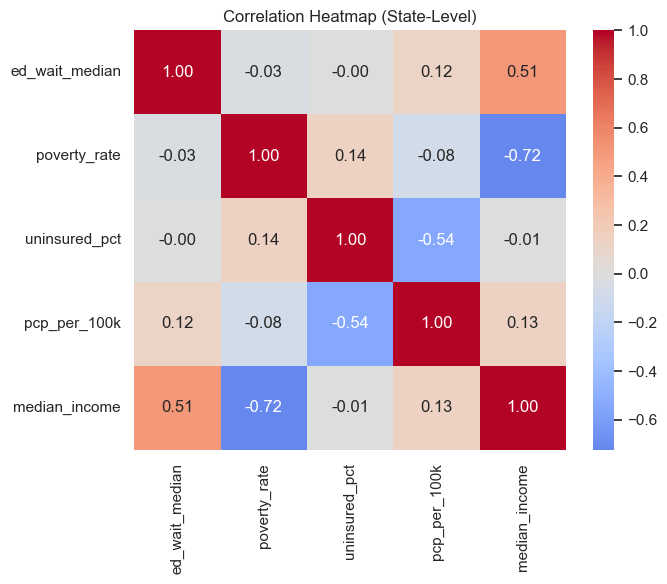

Saved: ..\results\eda_option_b_corr_heatmap.png
Saved: ..\modified_data\state_ed_wait_outliers_zscore.csv


,state_abbr,ed_wait_median,poverty_rate,uninsured_pct,pcp_per_100k,ed_wait_z,outlier_flag
8,DC,328.5,15.101882,22592.0,407.702505,4.189380,|z| > 1.5
22,MD,241.5,9.256503,360485.0,76.975423,2.054146,|z| > 1.5
21,MA,228.0,9.928116,185907.0,68.540371,1.722817,|z| > 1.5
43,RI,226.0,11.222118,46445.0,226.822024,1.673731,|z| > 1.5
9,DE,222.0,11.122978,58735.0,239.222652,1.575559,|z| > 1.5


In [22]:
corr_cols = ["ed_wait_median", "poverty_rate", "uninsured_pct", "pcp_per_100k", "median_income"]
corr_df = df_eda[corr_cols].copy()

fig, ax = plt.subplots(figsize=(7, 6))
mat = corr_df.corr(numeric_only=True)
sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (State-Level)")
fig.tight_layout()
heatmap_out = RESULTS / "eda_option_b_corr_heatmap.png"
fig.savefig(heatmap_out, dpi=220)
plt.show()
print("Saved:", heatmap_out)

df_outliers = df_eda[["state_abbr", "ed_wait_median", "poverty_rate", "uninsured_pct", "pcp_per_100k"]].copy()
resid_like = df_outliers["ed_wait_median"] - df_outliers["ed_wait_median"].mean()
std = resid_like.std()
df_outliers["ed_wait_z"] = np.where(std > 0, resid_like / std, np.nan)
df_outliers["outlier_flag"] = np.where(df_outliers["ed_wait_z"].abs() > 1.5, "|z| > 1.5", "")

outlier_out = MOD / "state_ed_wait_outliers_zscore.csv"
df_outliers.sort_values("ed_wait_z", ascending=False).to_csv(outlier_out, index=False)
print("Saved:", outlier_out)

df_outliers[df_outliers["outlier_flag"] != ""].sort_values("ed_wait_z", ascending=False)
